# Fine-tuning DTrOCR on IAM dataset
This is an example of fine-tuning DTrOCR on IAM dataset handwritten words from [Kaggle](https://www.kaggle.com/datasets/teykaicong/iamondb-handwriting-dataset). IAM Aachen splits can be downloaded [here](https://www.openslr.org/56/).

# Dataset folder structure
```
kmnist/
│
├── images/                              # PNG files
│   ├── 0.png                           
│   │   .
│   │   .
│   │   .
│   └── 1.png                          
│
└── labels/                                # txt files
	├── 0.txt
	.
	.
	.
	└── 1.txt
```

In [1]:
from pathlib import Path

MODEL='Version2'

EPOCHS=1

LR=1e-4

DATA_PATH = Path('data/kmnist')

DATASET_PATH = Path('preprocessed_data/kmnist')

DATA_PATH.mkdir(parents=True, exist_ok=True)

DATASET_PATH.mkdir(parents=True, exist_ok=True)

PREPROCESS_DATA = True

AUGMENT_DATA = False

# Build lists of images and texts

Number of training samples: 60000
Number of testing samples: 10000


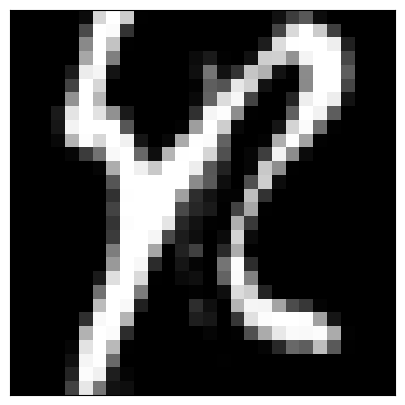

In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
if PREPROCESS_DATA or AUGMENT_DATA:
    test_imgs = np.load('../kmnist/kmnist-test-imgs.npz')['arr_0']
    test_labels = np.load('../kmnist/kmnist-test-labels.npz')['arr_0']
    train_imgs = np.load('../kmnist/kmnist-train-imgs.npz')['arr_0']
    train_labels = np.load('../kmnist/kmnist-train-labels.npz')['arr_0']
    print("Number of training samples:", len(train_imgs))
    print("Number of testing samples:", len(test_imgs))
    image = Image.fromarray(train_imgs[9]).convert('RGB')
    plt.figure(figsize=(10, 5))
    plt.imshow(np.array(image, dtype=np.uint8))
    plt.xticks([]), plt.yticks([])
    plt.show()

In [3]:
import csv
if PREPROCESS_DATA or AUGMENT_DATA:
    with open('../kmnist/kmnist_classmap.csv', mode='r') as table:
        reader = csv.reader(table)
        class_to_transcription = dict((rows[0], rows[2]) for rows in reader)
            
    print(class_to_transcription['0'])
    new_train_labels = list()
    for label in train_labels:
        new_train_labels.append(class_to_transcription[str(label)])
        
    print(train_labels[0], new_train_labels[0])
    new_test_labels = list()
    for label in test_labels:
        new_test_labels.append(class_to_transcription[str(label)])
        
    print(new_test_labels[1000])

お
8 れ
ま


In [4]:
from pathlib import Path
if PREPROCESS_DATA or AUGMENT_DATA:
    DATASET_PATH.mkdir(parents=True, exist_ok=True)
    Path('../models').mkdir(parents=True, exist_ok=True)

# Create images and labels from numpy arrays

In [5]:
if PREPROCESS_DATA or AUGMENT_DATA:
    data_dict = {}

    for ind in range(len(train_imgs)):
        savepath = str(DATASET_PATH / (str(ind) +'.png'))
        Image.fromarray(train_imgs[ind]).save(savepath)
        data_dict[savepath] = new_train_labels[ind]
        
    for ind in range(len(test_imgs)):
        savepath = str(DATASET_PATH / (str(ind) +'.png'))
        Image.fromarray(test_imgs[ind]).save(savepath)
        data_dict[savepath] = new_test_labels[ind]
        

In [8]:
from util.augmentation import augment_dataset
from util.data_processing import save_labels

if PREPROCESS_DATA:
    save_labels(data_dict, DATASET_PATH / 'labels.json')
if AUGMENT_DATA:
    augment_dataset(data_dict, 3, 3, 5)
    save_labels(data_dict, DATASET_PATH / 'augmented_labels.json')

# Build lists of images and texts

In [ ]:
import json
from pathlib import Path

with open(str(DATASET_PATH / 'augmented_labels.json'), 'r') as fp:
    data_dict = json.load(fp)

print(f"{len(data_dict.items())} dict elements")

words_files = list(data_dict.items())
print(words_files[0])


240000 dict elements
('preprocessed_data/kmnist/0.png', 'す')


In [8]:
import tqdm
import multiprocessing as mp
import xml.etree.ElementTree as ET
import functools
from PIL import Image
from dataclasses import dataclass


@dataclass
class Word:
    file_path: Path
    transcription: str
    

def get_word(word_file):
    words = []
    words.append(
        Word(
            file_path=word_file[0],
            transcription=word_file[1]
        )
    )
    return words


with mp.Pool(processes=mp.cpu_count()) as pool:
    words = list(
        tqdm.tqdm(
            pool.imap(get_word, words_files), 
            total=len(words_files),
            desc='Building dataset'
        )
    )
    
words = [word for words in words for word in words]

Building dataset: 100%|██████████| 240000/240000 [00:49<00:00, 4806.96it/s]


# Train test split

In [9]:
import numpy as np
train_word_records, validation_word_records, test_word_records = np.split(words, [int(len(words)*0.8), int(len(words)*0.9)])
print(f'Train size: {len(train_word_records)}; Validation size: {len(validation_word_records)}; Test size: {len(test_word_records)}')

Train size: 192000; Validation size: 24000; Test size: 24000


# Build dataset and dataloader

In [10]:
from dtrocr.processor import DTrOCRProcessor
from dtrocr.config import DTrOCRConfig
from pathlib import Path

from torch.utils.data import Dataset
    
class IAMDataset(Dataset):
    def __init__(self, words: list[Word], config: DTrOCRConfig):
        super(IAMDataset, self).__init__()
        self.words = words
        self.processor = DTrOCRProcessor(config, add_eos_token=False, add_bos_token=False)
        
    def __len__(self):
        return len(self.words)
    
    def __getitem__(self, item):
        inputs = self.processor(
            images=Image.open(self.words[item].file_path).convert('RGB'),
            texts=self.words[item].transcription,
            padding='max_length',
            return_tensors="pt",
            return_labels=True,
        )
        return {
            'pixel_values': inputs.pixel_values[0],
            'input_ids': inputs.input_ids[0],
            'input_attention_mask': inputs.input_attention_mask[0],
            'label_attention_mask': inputs.label_attention_mask[0],
            'labels': inputs.labels[0]
        }

config = DTrOCRConfig(
    # attn_implementation='flash_attention_2'
)

train_data = IAMDataset(words=train_word_records, config=config)
validation_data = IAMDataset(words=validation_word_records, config=config)
test_data = IAMDataset(words=test_word_records, config=config)

/home/kane/miniconda3/envs/JDict/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/home/kane/miniconda3/envs/JDict/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be 

In [11]:
from torch.utils.data import DataLoader
import multiprocessing as mp

train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=mp.cpu_count())
validation_dataloader = DataLoader(validation_data, batch_size=32, shuffle=False, num_workers=mp.cpu_count())
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=mp.cpu_count())

# Model

In [12]:
import torch
import os
torch.set_float32_matmul_precision('high')

from dtrocr.model import DTrOCRLMHeadModel

model = DTrOCRLMHeadModel(config)
model = torch.compile(model)
if os.path.exists(f'../models/{MODEL}.pt'):
    model.load_state_dict(torch.load(f'../models/{MODEL}.pt'))
model.to(device=0)

/tmp/ipykernel_3172340/1017931307.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'../models/{MODEL}.pt'))


OptimizedModule(
  (_orig_mod): DTrOCRLMHeadModel(
    (transformer): DTrOCRModel(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(4, 8), stride=(4, 8))
      )
      (token_embedding): Embedding(32000, 768)
      (positional_embedding): Embedding(256, 768)
      (hidden_layers): ModuleList(
        (0-11): 12 x GPT2Block(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): GPT2SdpaAttention(
            (c_attn): Conv1D()
            (c_proj): Conv1D()
            (attn_dropout): Dropout(p=0.1, inplace=False)
            (resid_dropout): Dropout(p=0.1, inplace=False)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): GPT2MLP(
            (c_fc): Conv1D()
            (c_proj): Conv1D()
            (act): NewGELUActivation()
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)


# Training

In [13]:
from typing import Tuple
import tqdm

def evaluate_model(model: torch.nn.Module, dataloader: DataLoader) -> Tuple[float, float]:
    # set model to evaluation mode
    model.eval()
    
    losses, accuracies = [], []
    with torch.no_grad():
        for inputs in tqdm.tqdm(dataloader, total=len(dataloader), desc=f'Evaluating test set'):
            inputs = send_inputs_to_device(inputs, device=0)
            outputs = model(**inputs)
            
            losses.append(outputs.loss.item())
            accuracies.append(outputs.accuracy.item())
    
    loss = sum(losses) / len(losses)
    accuracy = sum(accuracies) / len(accuracies)
    
    # set model back to training mode
    model.train()
    
    return loss, accuracy

def send_inputs_to_device(dictionary, device):
    return {key: value.to(device=device) if isinstance(value, torch.Tensor) else value for key, value in dictionary.items()}

use_amp = True
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
optimiser = torch.optim.Adam(params=model.parameters(), lr=LR)

train_losses, train_accuracies = [], []
validation_losses, validation_accuracies = [], []
test_losses, test_accuracies = [], []
for epoch in range(EPOCHS):
    epoch_losses, epoch_accuracies = [], []
    for inputs in tqdm.tqdm(train_dataloader, total=len(train_dataloader), desc=f'Epoch {epoch + 1}'):
        
        # set gradients to zero
        optimiser.zero_grad()
        
        # send inputs to same device as model
        inputs = send_inputs_to_device(inputs, device=0)
        
        # forward pass
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp):
            outputs = model(**inputs)
        
        # calculate gradients
        scaler.scale(outputs.loss).backward()
        
        # update weights
        scaler.step(optimiser)
        scaler.update()
        
        epoch_losses.append(outputs.loss.item())
        epoch_accuracies.append(outputs.accuracy.item())
        
    # store loss and metrics
    train_losses.append(sum(epoch_losses) / len(epoch_losses))
    train_accuracies.append(sum(epoch_accuracies) / len(epoch_accuracies))
    
    # tests loss and accuracy
    validation_loss, validation_accuracy = evaluate_model(model, validation_dataloader)
    validation_losses.append(validation_loss)
    validation_accuracies.append(validation_accuracy)
    
    test_loss, test_accuracy = evaluate_model(model, validation_dataloader)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)
                    
    print(f"Epoch: {epoch + 1} - Train loss: {train_losses[-1]}, Train accuracy: {train_accuracies[-1]}, Validation loss: {validation_losses[-1]}, Validation accuracy: {validation_accuracies[-1]}, Test loss: {test_losses[-1]}, Test accuracy: {test_accuracies[-1]}")

Evaluating test set: 100%|██████████| 750/750 [03:06<00:00,  4.02it/s]

Epoch: 1 - Train loss: 0.328845143638396, Train accuracy: 0.893348407253623, Validation loss: 0.18727981056148807, Validation accuracy: 0.9413149851957957, Test loss: 0.18727981056148807, Test accuracy: 0.9413149851957957


# Test

In [14]:
from dtrocr.model import DTrOCRLMHeadModel
from dtrocr.config import DTrOCRConfig
from dtrocr.processor import DTrOCRProcessor
import torch
import os
torch.save(model.state_dict(), f'../models/{MODEL}.pt')
# config = DTrOCRConfig()
# model = DTrOCRLMHeadModel(config)
# model = torch.compile(model)
if os.path.exists(f'../models/{MODEL}.pt'):
    model.load_state_dict(torch.load(f'../models/{MODEL}.pt'))
model.eval()
model.to('cpu')
test_processor = DTrOCRProcessor(DTrOCRConfig())

/tmp/ipykernel_3172340/3868614763.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'../models/{MODEL}.pt'))
/home/kane/miniconda3/envs/

In [15]:
import matplotlib

matplotlib.rc('font', family='TakaoPGothic')

や   tensor([[2]])


/home/kane/miniconda3/envs/JDict/lib/python3.12/site-packages/dtrocr-0.1.0-py3.12.egg/dtrocr/model.py:294: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  next_tokens = torch.argmax(torch.nn.functional.softmax(next_token_scores), dim=-1)


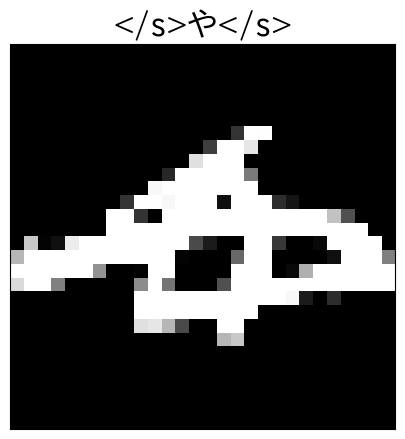

や   tensor([[2]])


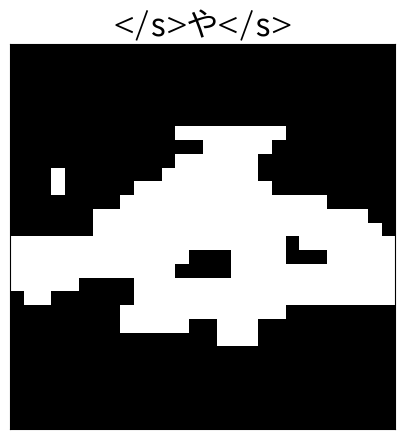

や   tensor([[2]])


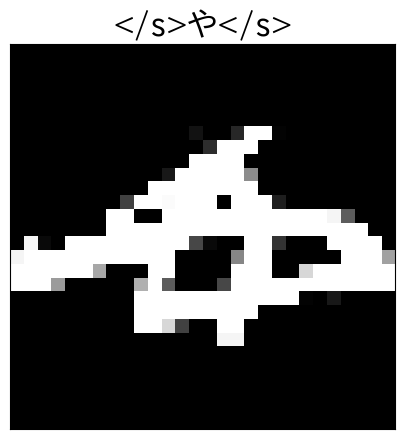

れ   tensor([[2]])


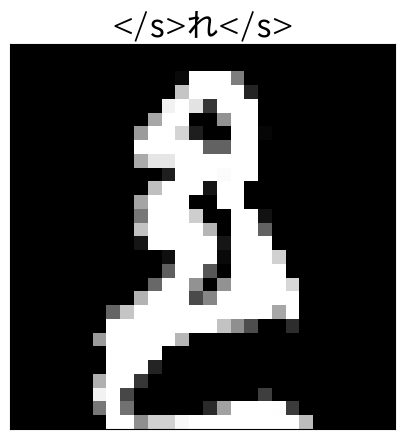

れ   tensor([[2]])


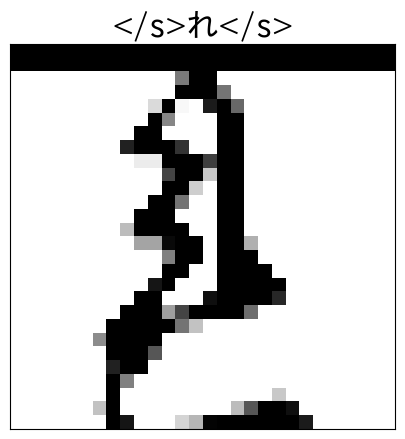

れ   tensor([[2]])


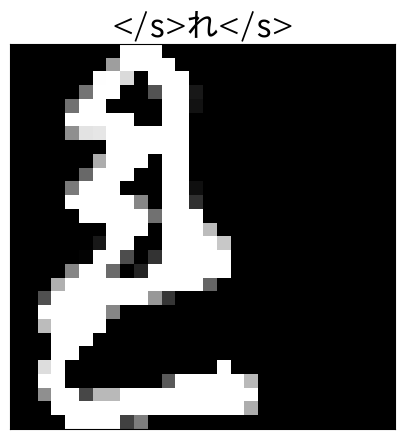

き   tensor([[2]])


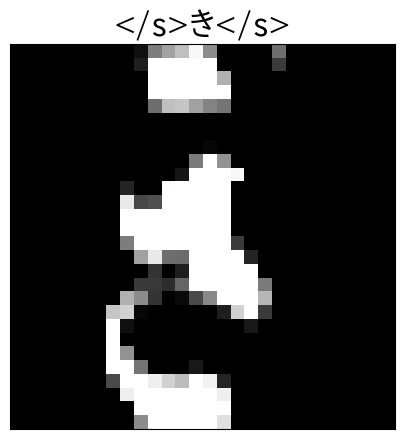

き   tensor([[2]])


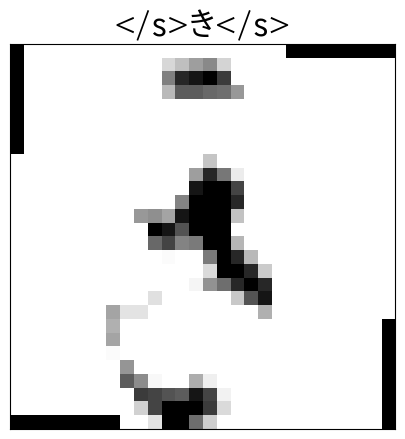

き   tensor([[2]])


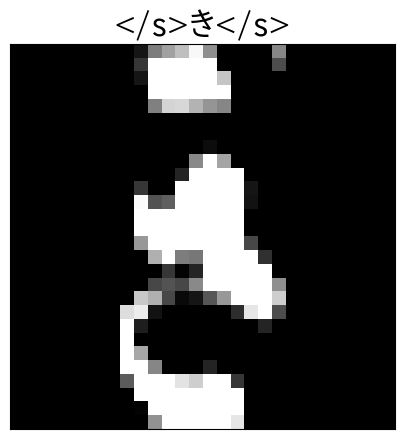

れ   tensor([[2]])


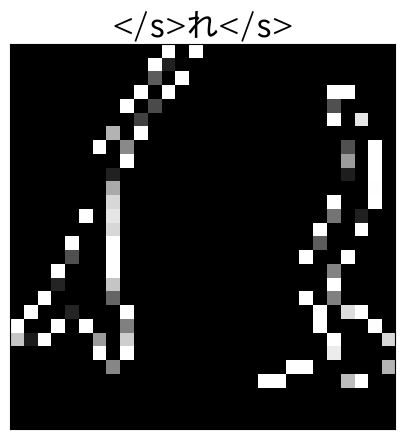

In [16]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

for test_word_record in test_word_records[:10]:
    image_file = test_word_record.file_path
    image = Image.open(image_file).convert('RGB')
    
    inputs = test_processor(
        images=image, 
        texts='',
        return_tensors='pt'
    )
    
    model_output = model.generate(
        inputs, 
        test_processor,
        num_beams=1
    )
    print(test_word_record.transcription, ' ', inputs.input_ids)

    predicted_text = test_processor.tokeniser.decode(model_output[0], skip_special_tokens=False)
    
    
    plt.figure(figsize=(10, 5))
    plt.title(predicted_text, fontsize=24)
    plt.imshow(np.array(image, dtype=np.uint8))
    plt.xticks([]), plt.yticks([])
    plt.show()

In [17]:
tokeniser = test_processor.tokeniser
print(tokeniser.pad_token)
print(tokeniser.eos_token)
print(tokeniser.bos_token)
print(tokeniser.model_max_length)

[PAD]
</s>
<s>
128
